In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')


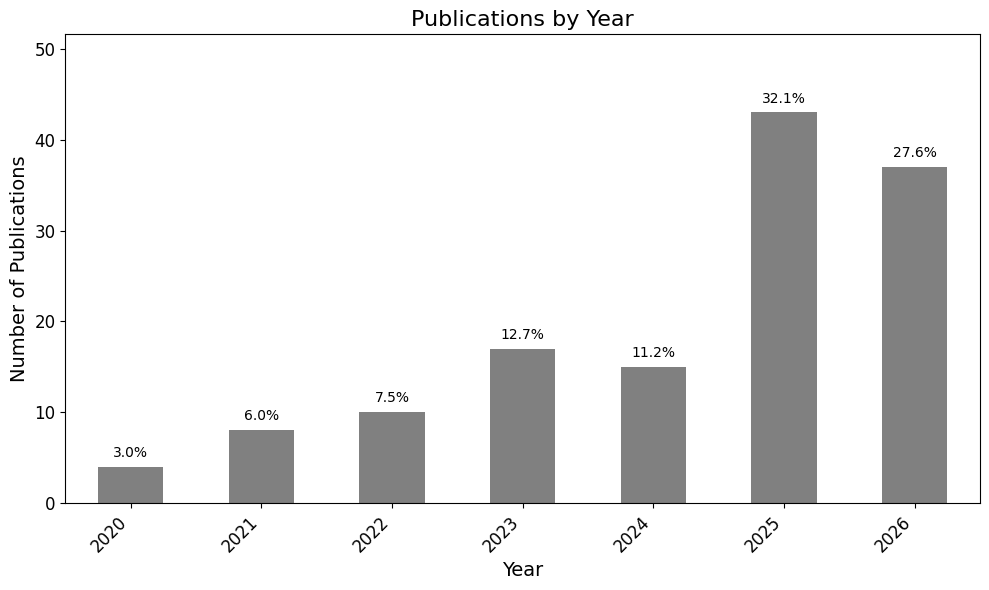

In [ ]:

# Calculate frequency of 'year' feature (re-added for cell independence)
year_counts = data['Year'].value_counts().sort_index()

# Calculate percentages
total_publications = year_counts.sum()
percentages = (year_counts / total_publications) * 100

# Create a bar chart for year_counts
fig, ax = plt.subplots(figsize=(10, 6))
year_counts.plot(kind='bar', ax=ax, color='#808080')

# Add title and labels with adjusted font sizes
ax.set_title('Publications by Year', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Number of Publications', fontsize=14)

# Rotate x-axis labels for better readability and adjust font size
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Adjust y-axis limits to provide more space
ax.set_ylim(0, year_counts.max() * 1.2) # Set y-axis limit to be 20% higher than max value

# Annotate each bar with its percentage on top
for i, p in enumerate(ax.patches):
    ax.annotate(f'{percentages.iloc[i]:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontsize=10, color='black')

# Annotate each bar with the number of publications inside the bar
#for i, p in enumerate(ax.patches):
#    ax.annotate(f'{year_counts.iloc[i]}',
#                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
#                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('Fig 3 publications_by_year_bar_chart.svg', format='svg')
plt.show()

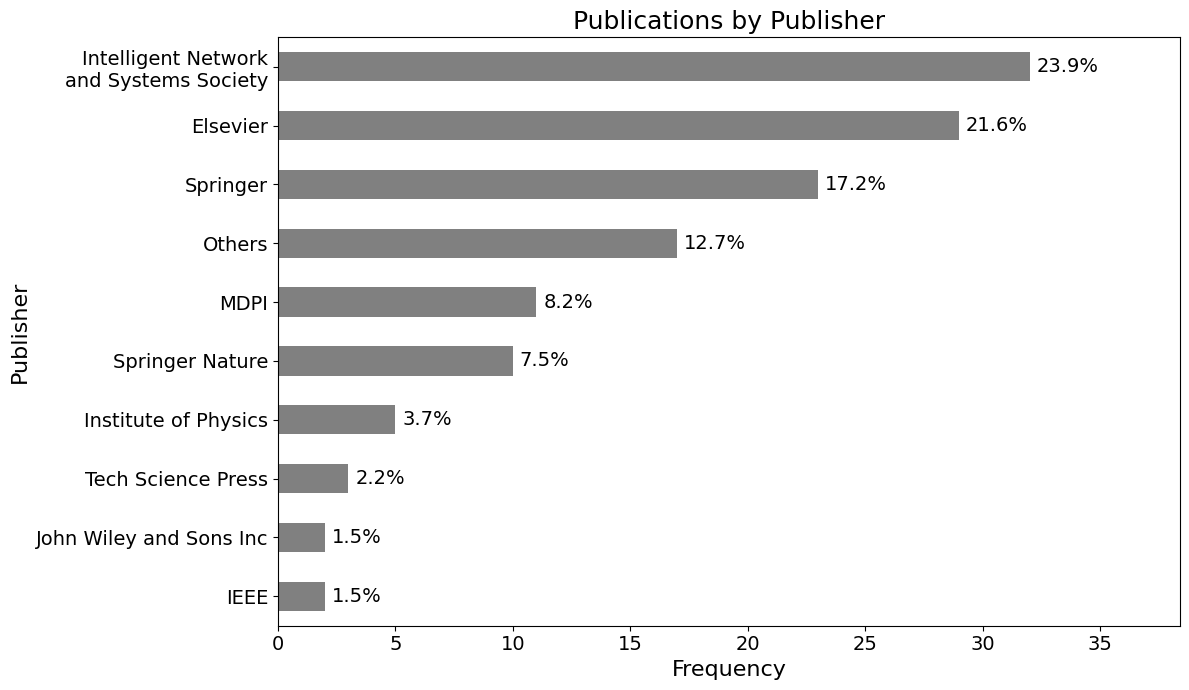

In [ ]:
import matplotlib.pyplot as plt

# Calculate value counts for 'Publisher'
publisher_counts = data['Publisher'].value_counts()

# Identify publishers to keep individually and define a threshold
# Based on the kernel state, 'John Wiley and Sons Inc' has 3 counts.
# Let's keep publishers with more than 2 counts individually.
threshold = 1 # Publishers with 3 or more counts will be kept individually

# Get top publishers based on the threshold
top_publishers = publisher_counts[publisher_counts > threshold]

# Sum up the counts of the remaining publishers into an 'Others' category
others_count = publisher_counts[publisher_counts <= threshold].sum()

# Create a new Series for the plot data, adding 'Others' if it exists
if others_count > 0:
    plot_data = pd.concat([top_publishers, pd.Series({'Others': others_count})])
else:
    plot_data = top_publishers

# Recalculate percentages for the new plot_data
total_publications_new = plot_data.sum()
percentages = (plot_data / total_publications_new) * 100

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(12, 7)) # Adjust figure size for better readability
plot_data.sort_values().plot(kind='barh', ax=ax, color='#808080') # Plot on the created axes with medium gray color, changed to barh and sorted

# Add title and labels with increased font sizes
ax.set_title('Publications by Publisher', fontsize=18)
ax.set_xlabel('Frequency', fontsize=16) # Swapped xlabel and ylabel
ax.set_ylabel('Publisher', fontsize=16) # Swapped xlabel and ylabel

# Rotate y-axis labels for better readability and adjust font size
plt.yticks(fontsize=14) # Changed to yticks for horizontal bar chart

# Adjust x-axis limits and ticks for better visualization of percentages
max_freq = plot_data.max() if not plot_data.empty else 0
ax.set_xlim(0, max_freq * 1.2) # Set x-axis limit to be 20% higher than max value
plt.xticks(np.arange(0, max_freq * 1.2 + 1, 5), fontsize=14) # Set ticks with a step of 5, changed to xticks

# Annotate each bar with its percentage (increased font size)
for i, (publisher_name, count) in enumerate(plot_data.sort_values().items()):
    percentage_value = percentages.loc[publisher_name]
    ax.annotate(f'{percentage_value:.1f}%',
                (count, i), # Position at the end of the bar
                ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                fontsize=14, color='black') # Increased fontsize to 12, increased xytext offset

# Modify the specific y-axis label to be on two lines
current_labels = [item.get_text() for item in ax.get_yticklabels()]
if 'Intelligent Network and Systems Society' in current_labels:
    idx = current_labels.index('Intelligent Network and Systems Society')
    current_labels[idx] = 'Intelligent Network\nand Systems Society'
    ax.set_yticklabels(current_labels)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('Fig 4 publishers_bar_chart_grouped.svg', format='svg')
plt.show()

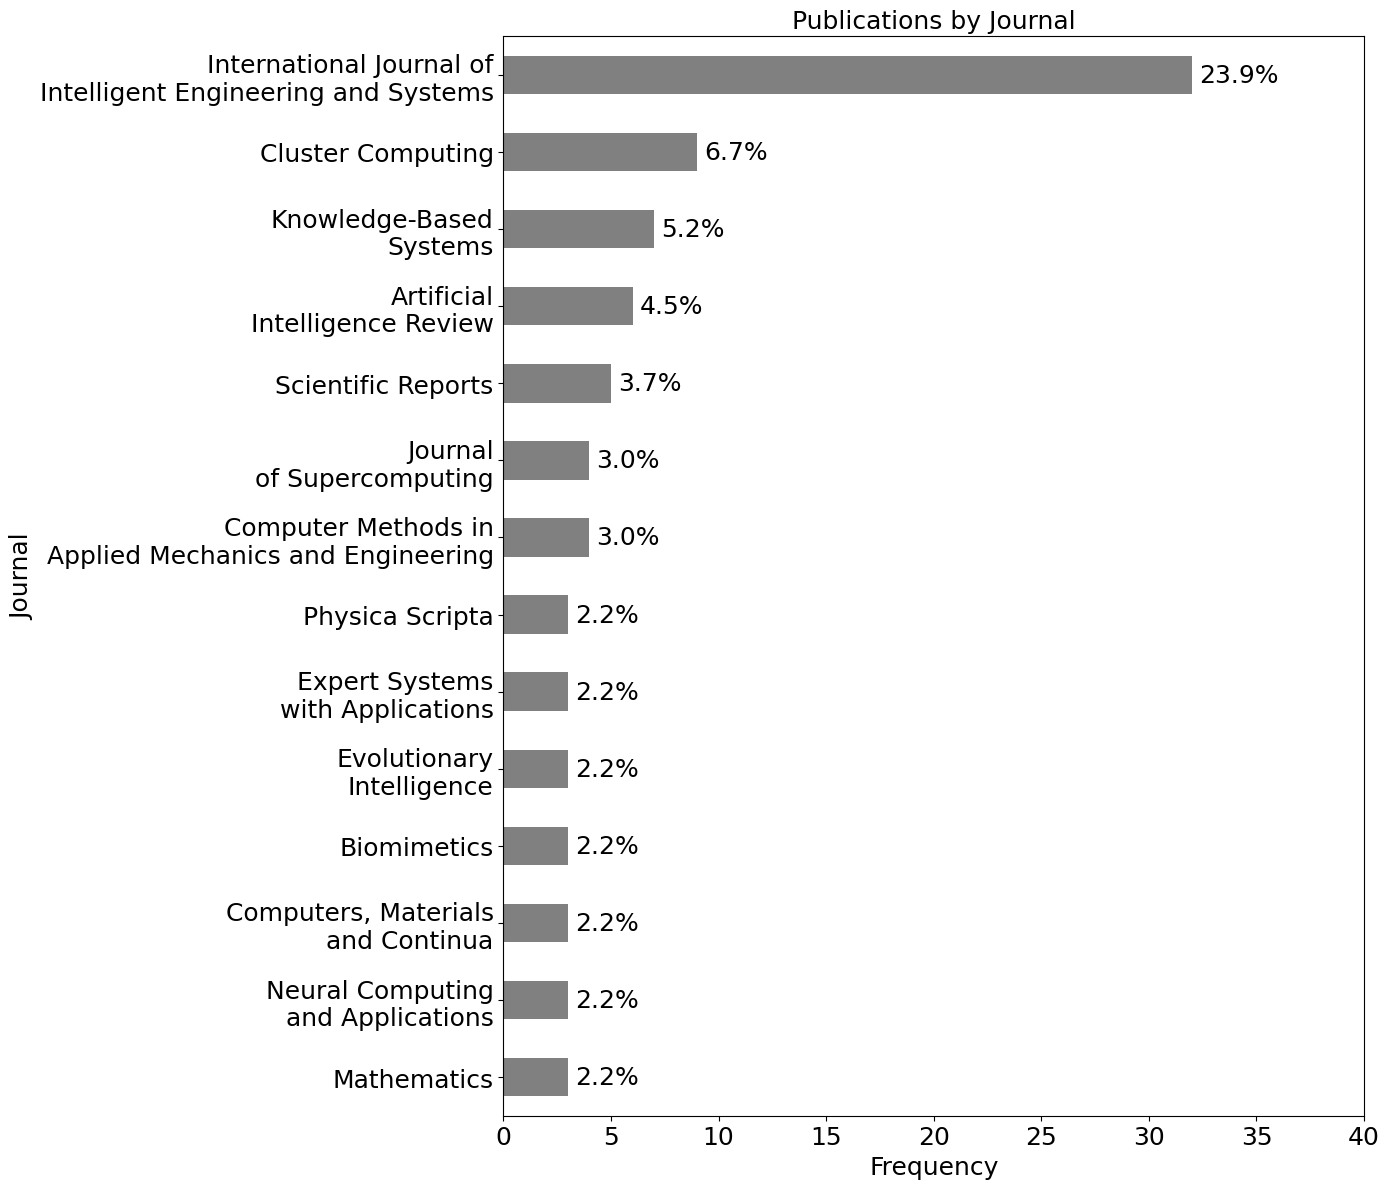

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Import pandas

# Load the data (assuming the file path is correct as in previous cells)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# Calculate value counts for 'Source title'
source_title_counts = data['Journal'].value_counts()

# Define the threshold for grouping
threshold = 2 # Group frequencies of 2 or less into 'Others'

# Get top source titles based on the threshold
top_source_titles = source_title_counts[source_title_counts > threshold]

# Sum up the counts of the remaining source titles into an 'Others' category
others_count = source_title_counts[source_title_counts <= threshold].sum()

# Create a new Series for the plot data, WITHOUT adding 'Others' category
plot_data = top_source_titles

# Recalculate percentages using the total number of records in the DataFrame as the denominator
total_records_for_percentage = len(data)
percentages = (plot_data / total_records_for_percentage) * 100

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(14, 12)) # Adjust figure size for better readability, increased height to 12
plot_data.sort_values().plot(kind='barh', ax=ax, color='#808080') # Plot on the created axes with medium gray color, sorted for better visualization

# Add title and labels
ax.set_title('Publications by Journal', fontsize=18)
ax.set_xlabel('Frequency', fontsize=18) # X-axis is now Frequency
ax.set_ylabel('Journal', fontsize=18) # Y-axis is now Journal

# Adjust tick font sizes
plt.xticks(fontsize=18) # X-axis ticks for Frequency
plt.yticks(fontsize=18) # Y-axis ticks for Journal labels

# Adjust x-axis limits and ticks for better visualization of percentages
max_freq = plot_data.max() if not plot_data.empty else 0
# Extend x-axis limit to 50 for a wider range of ticks
ax.set_xlim(0, 40)
ax.set_xticks(np.arange(0, 41, 5)) # Set ticks with a step of 5 up to 50

# Annotate each bar with its percentage
for i, (journal_name, count) in enumerate(plot_data.sort_values().items()):
    percentage_value = percentages.loc[journal_name] # Look up percentage by journal_name
    ax.annotate(f'{percentage_value:.1f}%',
                (count, i), # Position at the end of the bar
                ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                fontsize=18, color='black')

# Split long y-axis labels into two lines for better readability
ax = plt.gca() # Get the current axes
current_labels = [item.get_text() for item in ax.get_yticklabels()] # Get y-axis labels for horizontal bar chart
new_labels = []
for label in current_labels:
    if len(label) > 20 and ' ' in label: # Heuristic: if label is long and contains a space
        parts = label.split(' ')
        if len(parts) > 1:
            mid_point = len(parts) // 2
            # Try to split around the middle space
            new_label = ' '.join(parts[:mid_point]) + '\n' + ' '.join(parts[mid_point:])
        else: # No space to split, but still long
            new_label = label # Keep as is
    else:
        new_label = label
    new_labels.append(new_label)
ax.set_yticklabels(new_labels)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('Fig 5 journal_bar_chart.svg', format='svg') # Save with a new name for grouped chart
plt.show()

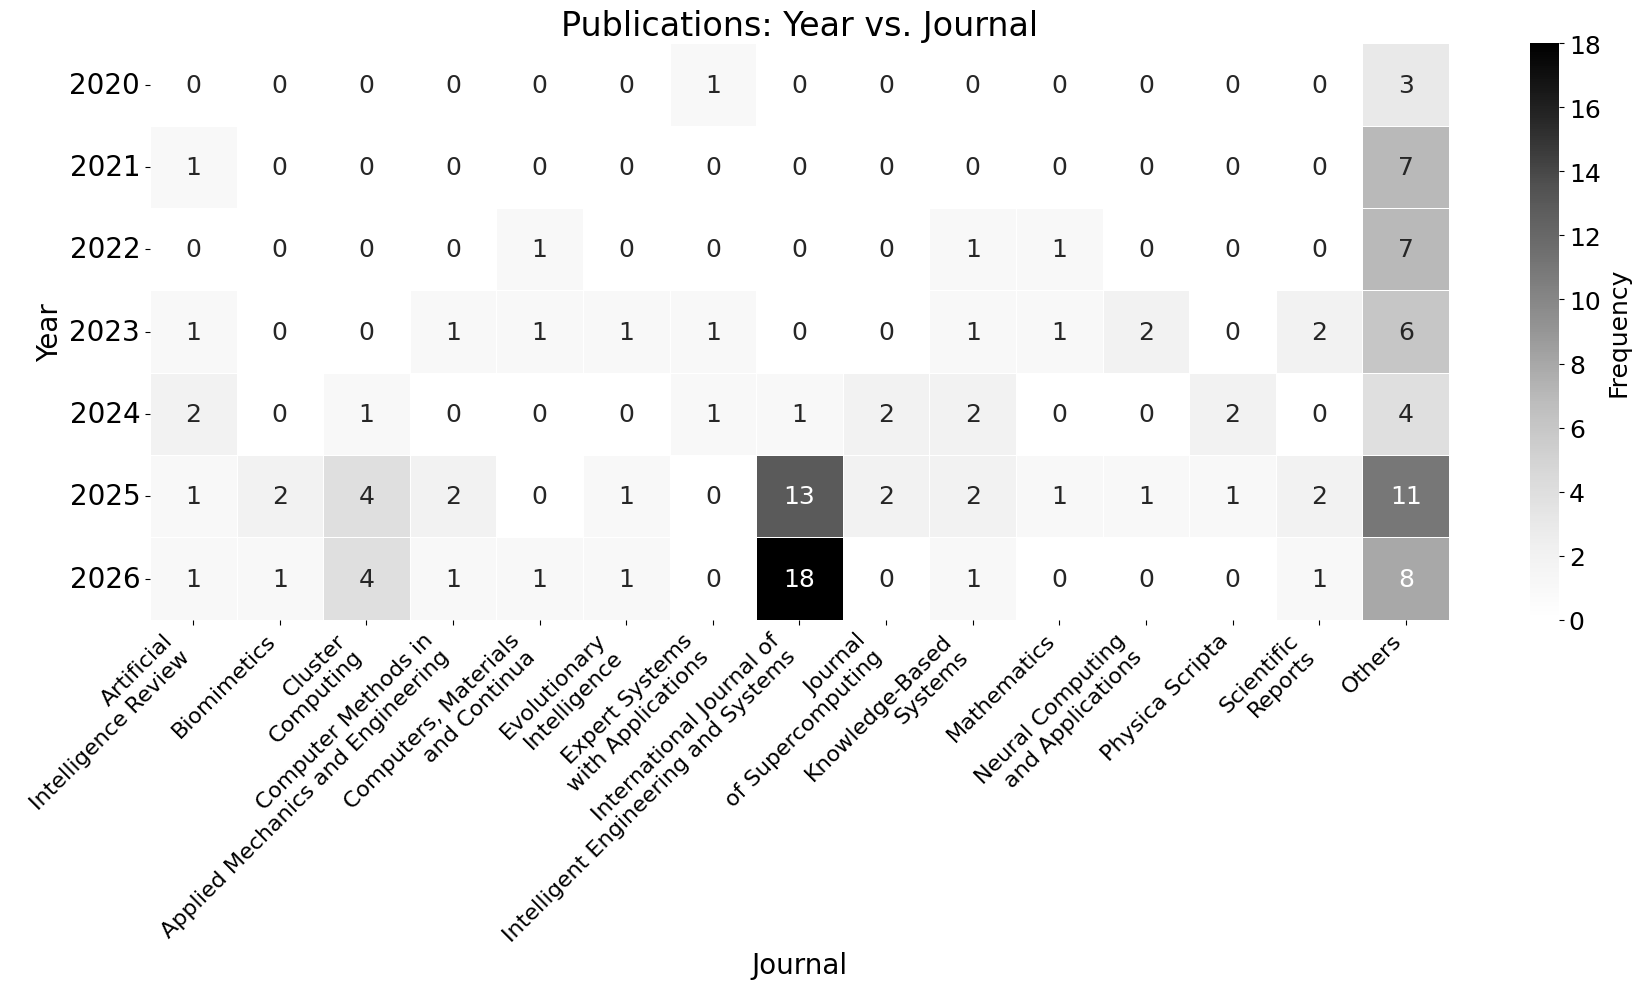

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Cargar los datos (asegurando la independencia de la celda)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# Recalcular las frecuencias de 'Source title' para aplicar la agrupación
source_title_counts = data['Journal'].value_counts()
threshold = 2 # Mismo umbral que el gráfico de barras anterior

# Crear un mapeo para agrupar los títulos de origen
source_title_mapping_keys = source_title_counts[source_title_counts > threshold].index.tolist()

data['Grouped Journal'] = data['Journal'].apply(
    lambda x: x if x in source_title_mapping_keys else 'Others'
)

# Crear la tabla de contingencia (pivot table) de Año vs. Título de Origen Agrupado (frecuencias)
contingency_table = pd.crosstab(data['Year'], data['Grouped Journal'])

# Asegurar que 'Others' sea la última columna si existe en la tabla de frecuencias
if 'Others' in contingency_table.columns:
    cols = contingency_table.columns.tolist()
    cols.remove('Others')
    cols.append('Others')
    contingency_table = contingency_table[cols]

# Eliminar el cálculo de porcentajes y usar la tabla de contingencia original

# Crear el mapa de calor
plt.figure(figsize=(18, 10)) # Ajustar el tamaño de la figura para una mejor visualización
ax = sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Greys', linewidths=.5, cbar_kws={'label': 'Frequency'}, annot_kws={'fontsize': 18}) # Changed data back to contingency_table, fmt to 'd', and cbar_kws label to 'Frequency'

# Get the colorbar object and set its label fontsize separately
cbar = ax.collections[0].colorbar
cbar.set_label('Frequency', fontsize=18) # Changed label back to Frequency
cbar.ax.tick_params(labelsize=18) # Set fontsize for colorbar ticks

# Añadir título y etiquetas en inglés
plt.title('Publications: Year vs. Journal', fontsize=24) # Increased fontsize from 20 to 24
plt.xlabel('Journal', fontsize=20)
plt.ylabel('Year', fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=16)
plt.yticks(rotation=0, fontsize=20)

# --- BEGIN MODIFICATION for multiline x-axis labels ---
ax = plt.gca() # Get the current axes
current_labels = [item.get_text() for item in ax.get_xticklabels()]
new_labels = []
for label in current_labels:
    if len(label) > 15 and ' ' in label: # Heuristic: if label is long and contains a space
        parts = label.split(' ')
        if len(parts) > 1:
            mid_point = len(parts) // 2
            # Try to split around the middle space
            new_label = ' '.join(parts[:mid_point]) + '\n' + ' '.join(parts[mid_point:])
        else: # No space to split, but still long
            new_label = label # Keep as is, rotation should help
    else:
        new_label = label
    new_labels.append(new_label)
ax.set_xticklabels(new_labels)
# --- END MODIFICATION for multiline x-axis labels ---

plt.tight_layout() # Ajustar el diseño para evitar la superposición de etiquetas
plt.savefig('Fig 6 year_journal_heatmap.svg', format='svg') # Guardar la figura con un nuevo nombre
plt.show()

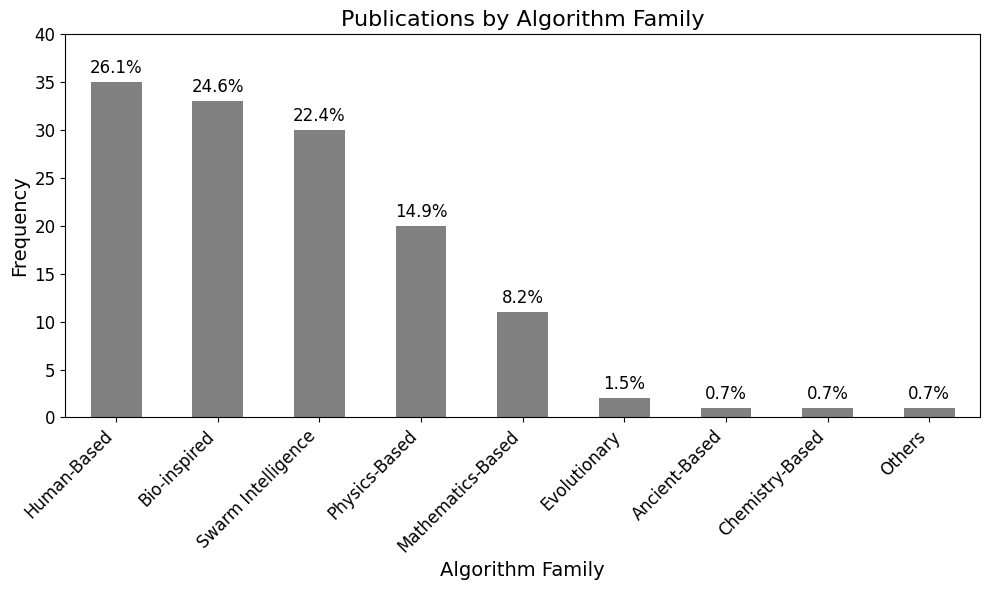

In [ ]:
import matplotlib.pyplot as plt

# Calculate value counts for 'Algorithm Family'
counts = data['Algorithm Family'].value_counts()

# Calculate percentages
total = counts.sum()
percentages = (counts / total) * 100

# Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6)) # Create a figure and a set of subplots
counts.plot(kind='bar', ax=ax, color='#808080') # Plot on the created axes with medium gray color

# Annotate each bar with its percentage
for i, p in enumerate(ax.patches):
    ax.annotate(f'{percentages.iloc[i]:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontsize=12, color='black') # Increased fontsize

ax.set_title('Publications by Algorithm Family', fontsize=16) # Increased fontsize
ax.set_xlabel('Algorithm Family', fontsize=14) # Increased fontsize
ax.set_ylabel('Frequency', fontsize=14) # Increased fontsize
plt.xticks(rotation=45, ha='right', fontsize=12) # Rotate x-axis labels for better readability, increased fontsize
plt.yticks(fontsize=12) # Increased fontsize

# Adjust y-axis ticks to a maximum of 40
ax.set_ylim(0, 40)
ax.set_yticks(np.arange(0, 41, 5)) # Set ticks from 0 to 40 with step 5

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('Fig 7 algorithm_family_bar_chart.svg', format='svg')
plt.show()

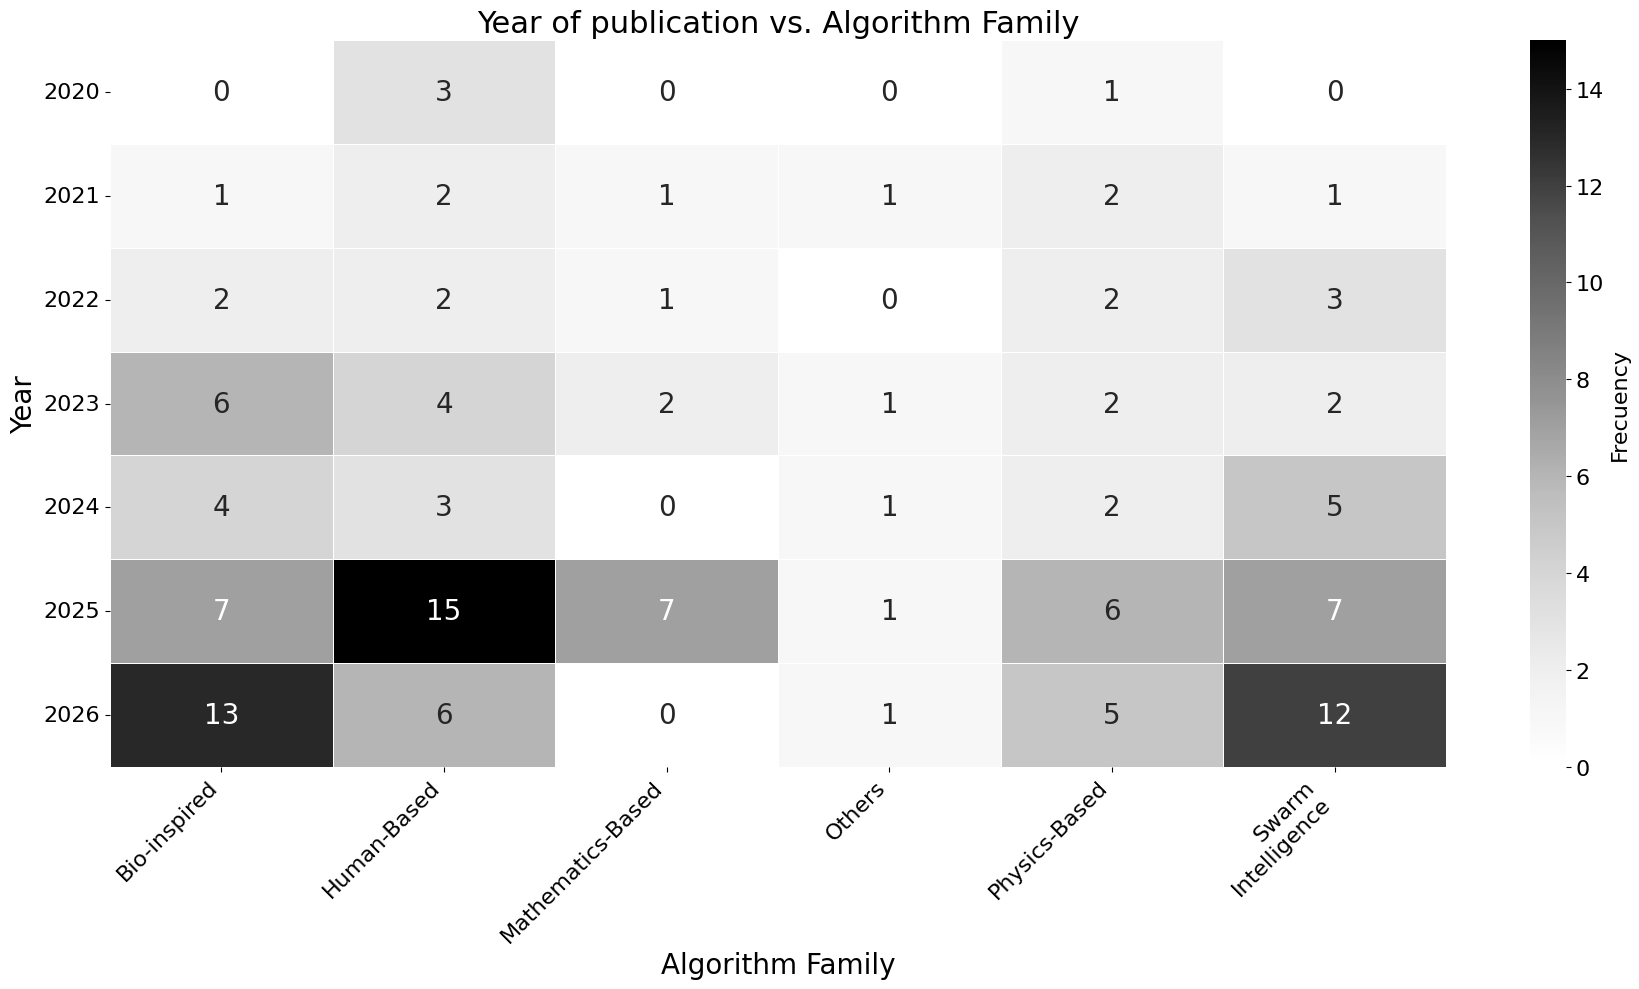

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Cargar los datos (asegurando la independencia de la celda)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# Recalcular las frecuencias de 'Algorithm Family' para aplicar la agrupación
algorithm_family_counts = data['Algorithm Family'].value_counts()

# Define el umbral para agrupar (por ejemplo, agrupar frecuencias de 2 o menos en 'Others')
threshold = 2

# Crear un mapeo para agrupar las familias de algoritmos
algorithm_family_mapping_keys = algorithm_family_counts[algorithm_family_counts > threshold].index.tolist()

data['Grouped Algorithm Family'] = data['Algorithm Family'].apply(
    lambda x: x if x in algorithm_family_mapping_keys else 'Others'
)

# Crear la tabla de contingencia (pivot table) de Año vs. Familia de Algoritmos Agrupada
contingency_table_alg = pd.crosstab(data['Year'], data['Grouped Algorithm Family'])

# Asegurar que 'Otros' sea la última columna si existe
if 'Otros' in contingency_table_alg.columns:
    cols_alg = contingency_table_alg.columns.tolist()
    cols_alg.remove('Others')
    cols_alg.append('Others')
    contingency_table_alg = contingency_table_alg[cols_alg]

# Crear el mapa de calor
plt.figure(figsize=(18, 10)) # Ajustar el tamaño de la figura para una mejor visualización
ax = sns.heatmap(contingency_table_alg, annot=True, fmt='d', cmap='Greys', linewidths=.5, cbar_kws={'label': 'Frequency'}, annot_kws={'fontsize': 20}) # Increased fontsize

# Get the colorbar object and set its label fontsize separately
cbar = ax.collections[0].colorbar
cbar.set_label('Frecuency', fontsize=16) # Set fontsize here
cbar.ax.tick_params(labelsize=16) # Set fontsize for colorbar ticks

# Añadir título y etiquetas
plt.title('Year of publication vs. Algorithm Family', fontsize=22) # Increased fontsize
plt.xlabel('Algorithm Family', fontsize=20) # Increased fontsize
plt.ylabel('Year', fontsize=20) # Increased fontsize
plt.xticks(rotation=45, ha='right', fontsize=16) # Increased fontsize
plt.yticks(rotation=0, fontsize=16) # Increased fontsize

# --- BEGIN MODIFICATION for multiline x-axis labels (optional, based on content) ---
ax = plt.gca() # Get the current axes
current_labels = [item.get_text() for item in ax.get_xticklabels()]
new_labels = []
for label in current_labels:
    if len(label) > 15 and ' ' in label: # Heuristic: if label is long and contains a space
        parts = label.split(' ')
        if len(parts) > 1:
            mid_point = len(parts) // 2
            # Try to split around the middle space
            new_label = ' '.join(parts[:mid_point]) + '\n' + ' '.join(parts[mid_point:])
        else: # No space to split, but still long
            new_label = label # Keep as is, rotation should help
    else:
        new_label = label
    new_labels.append(new_label)
ax.set_xticklabels(new_labels)
# --- END MODIFICATION for multiline x-axis labels ---

plt.tight_layout() # Ajustar el diseño para evitar la superposición de etiquetas
plt.savefig('Fig 8 year_algorithm_family_heatmap.svg', format='svg') # Guardar la figura
plt.show()

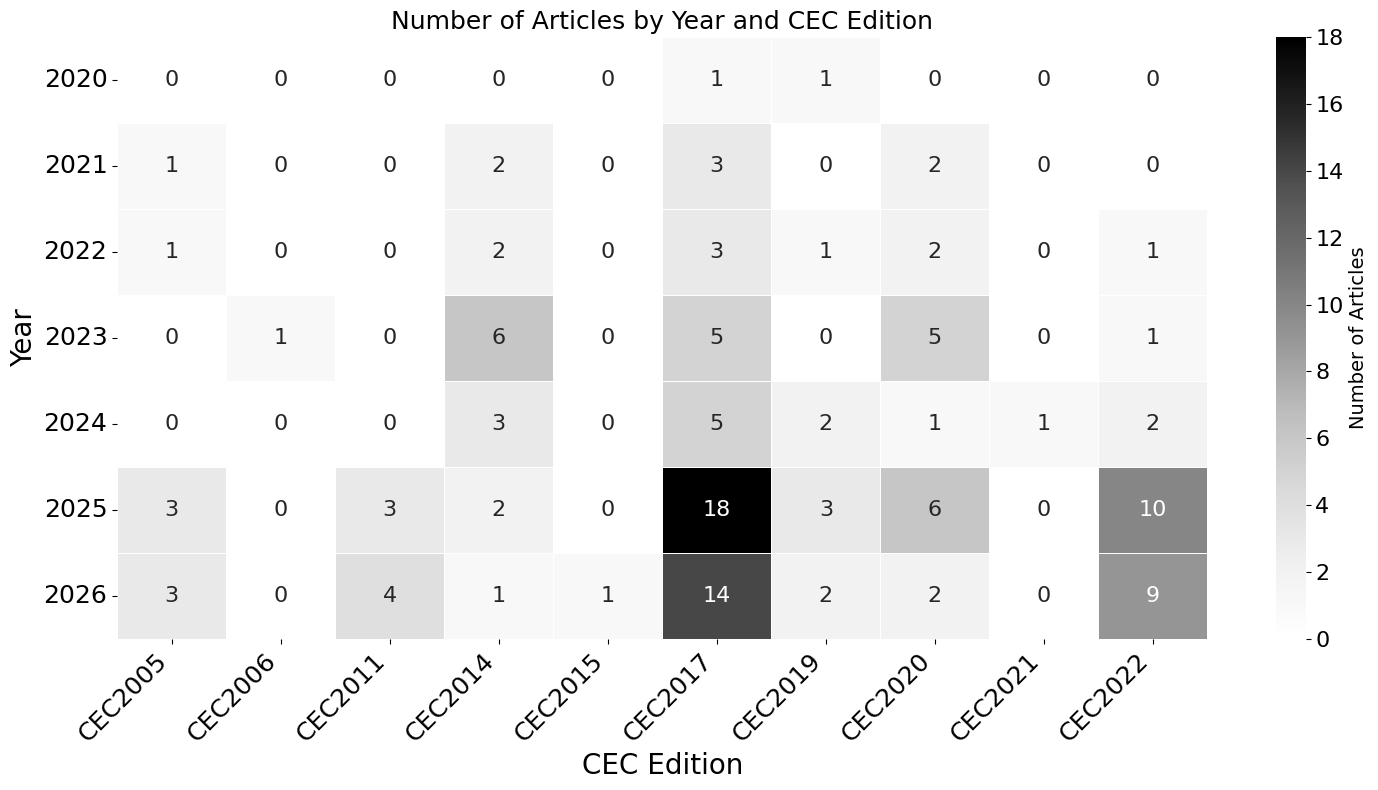

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re # Import regex module

# Ensure data is loaded (for cell independence)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# Define the target CEC editions and years
target_cec_editions = ['CEC2005', 'CEC2006', 'CEC2011', 'CEC2014', 'CEC2015', 'CEC2017', 'CEC2019', 'CEC2020', 'CEC2021', 'CEC2022']
target_years = range(2020, 2027) # Years from 2020 to 2026

# Initialize a dictionary to store counts
cecs_per_year_counts = {year: {cec: 0 for cec in target_cec_editions} for year in target_years}

# Debugging: List to store processed multi-CEC entries for inspection
processed_multi_cecs_examples = []

# Iterate through the DataFrame to handle multiple CEC Editions per record
for index, row in data.iterrows():
    year = row['Year']
    cec_edition_raw = row['CEC Edition']

    # Ensure year is in target_years and CEC Edition is not NaN
    if year in target_years and pd.notna(cec_edition_raw):
        cec_edition_str = str(cec_edition_raw).strip() # Ensure it's a string and strip outer whitespace

        # Use regex to split by semicolon, optionally surrounded by spaces
        individual_cecs = [cec.strip() for cec in re.split(r';\s*', cec_edition_str) if cec.strip() in target_cec_editions]

        if len(individual_cecs) > 1: # If this row contained multiple valid CECs
            processed_multi_cecs_examples.append(f"Year {year}: '{cec_edition_raw}' -> {individual_cecs}")

        for cec in individual_cecs:
            if cec in target_cec_editions: # Double-check, though already filtered
                cecs_per_year_counts[year][cec] += 1

# Convert the dictionary to a DataFrame
contingency_table_cec = pd.DataFrame.from_dict(cecs_per_year_counts, orient='index')

# Ensure the columns are in the desired order and fill any missing with 0
# Reindex also handles cases where a CEC edition might not have any counts after processing
contingency_table_cec = contingency_table_cec.reindex(columns=target_cec_editions, fill_value=0)
contingency_table_cec.index.name = 'Year'

# Create the heatmap
plt.figure(figsize=(15, 8)) # Adjust figure size for better visualization
ax = sns.heatmap(contingency_table_cec, annot=True, fmt='d', cmap='Greys', linewidths=.5, cbar_kws={'label': 'Number of Articles'}, annot_kws={'fontsize': 16}) # Removed fontsize from cbar_kws

cbar = ax.collections[0].colorbar
cbar.set_label('Frecuency', fontsize=16) # Set fontsize here
cbar.ax.tick_params(labelsize=16) # Set fontsize for colorbar ticks

# Get the colorbar object and set its label fontsize separately
cbar = ax.collections[0].colorbar
cbar.set_label('Number of Articles', fontsize=14) # Set fontsize here

# Add title and labels in English
plt.title('Number of Articles by Year and CEC Edition', fontsize=18)
plt.xlabel('CEC Edition', fontsize=20)
plt.ylabel('Year', fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=18)
plt.yticks(rotation=0, fontsize=18)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('Fig 9 year_cec_edition_heatmap.svg', format='svg') # Save the figure
plt.show()

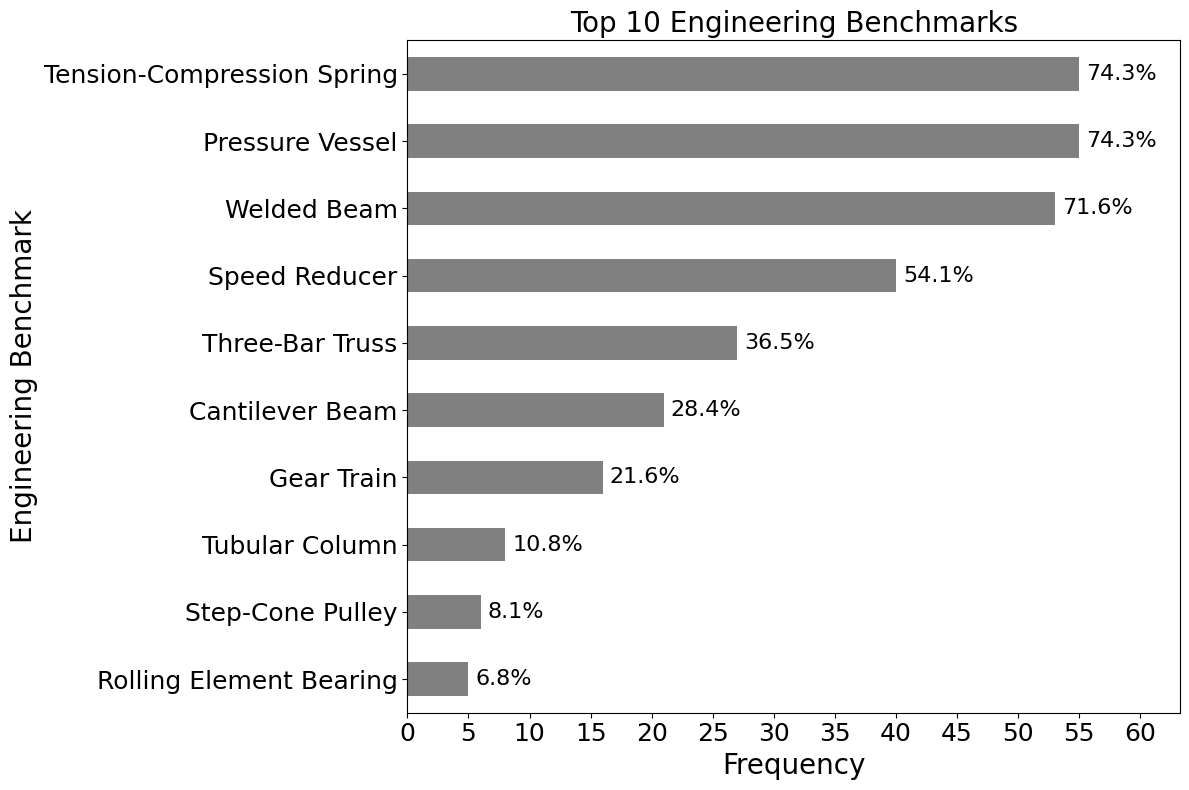

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure data is loaded (for cell independence)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# --- New calculation for the denominator of the percentages ---
# Count the number of records (rows) that are NOT 'Not Applicable' or 'Not available'
num_valid_records_benchmarks = 0
for entry in data['Engineering Benchmarks'].dropna():
    if entry.strip().lower() not in ['not applicable', 'not available']:
        num_valid_records_benchmarks += 1
# ----------------------------------------------------------

# Initialize a list to hold all individual benchmarks
all_benchmarks = []

# Iterate through the 'Engineering Benchmarks' column
for entry in data['Engineering Benchmarks'].dropna():
    if entry.strip().lower() not in ['not applicable', 'not available']:
        # Split by semicolon and extend the list, stripping whitespace from each benchmark
        all_benchmarks.extend([benchmark.strip() for benchmark in entry.split(';')])

# Get the frequency of each benchmark
benchmark_counts = pd.Series(all_benchmarks).value_counts()

# Select the top 10 most frequent benchmarks
top_10_benchmarks = benchmark_counts.head(10)

# Calculate percentages for the top 10 using the new denominator
# If no valid records, percentages are 0 to avoid division by zero.
if num_valid_records_benchmarks > 0:
    percentages_top_10 = (top_10_benchmarks / num_valid_records_benchmarks) * 100
else:
    percentages_top_10 = pd.Series(0, index=top_10_benchmarks.index)

# Create the horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))
top_10_benchmarks.sort_values().plot(kind='barh', ax=ax, color='#808080') # Sort for better visualization

# Add title and labels
ax.set_title('Top 10 Engineering Benchmarks', fontsize=20) # Increased fontsize
ax.set_xlabel('Frequency', fontsize=20) # Increased fontsize
ax.set_ylabel('Engineering Benchmark', fontsize=20) # Increased fontsize

# Set x-axis limits and ticks to better visualize percentages
max_frequency = top_10_benchmarks.max()
ax.set_xlim(0, max_frequency * 1.15) # Extend x-axis by 15% to give more space for annotations
ax.set_xticks(np.arange(0, max_frequency * 1.15 + 1, 5)) # Set ticks every 5 units

# Increase tick label font size
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Annotate each bar with its frequency and percentage
for i, (benchmark, count) in enumerate(top_10_benchmarks.sort_values().items()):
    # Retrieve the percentage calculated with the new denominator
    percentage = percentages_top_10.loc[benchmark]
    ax.annotate(f'{percentage:.1f}%',
                (count, i),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=16, color='black') # Increased fontsize

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('Fig 10 top_10_engineering_benchmarks_bar_chart.svg', format='svg')
plt.show()

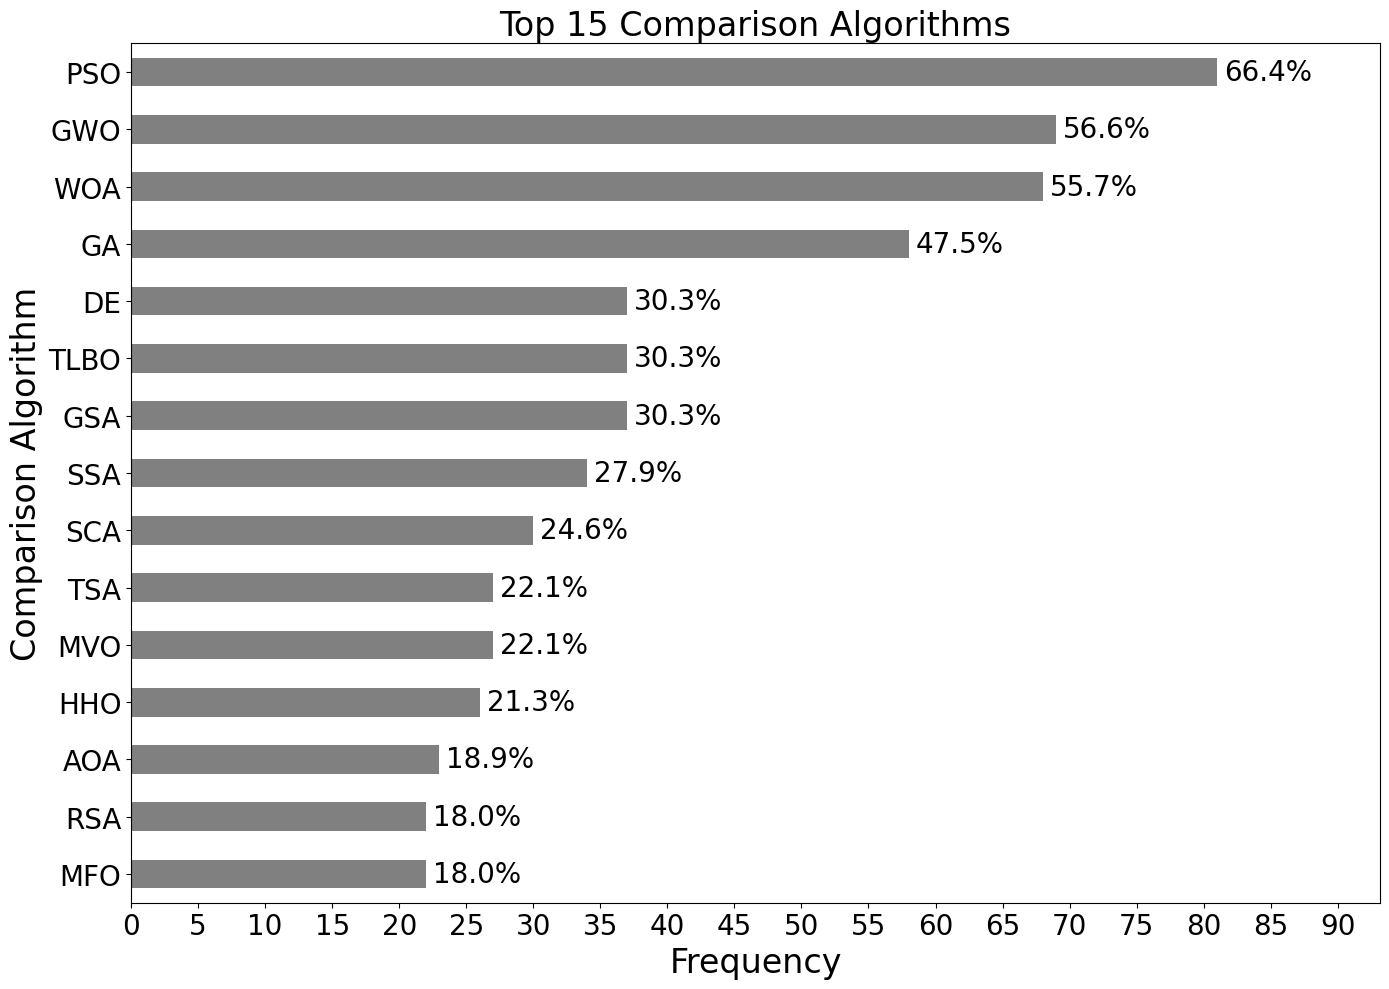

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure data is loaded (for cell independence)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# --- New calculation for the denominator of the percentages ---
# Count the number of records (rows) that are NOT 'Not Applicable' or 'Not available'
num_valid_records_comparison_algorithms = 0
for entry in data['Comparison Algorithms'].dropna():
    if entry.strip().lower() not in ['not reported', 'not available']:
        num_valid_records_comparison_algorithms += 1
# ----------------------------------------------------------

# Initialize a list to hold all individual comparison algorithms
all_comparison_algorithms = []

# Iterate through the 'Comparison Algorithms' column
for entry in data['Comparison Algorithms'].dropna():
    if entry.strip().lower() not in ['not applicable', 'not available']:
        # Split by semicolon and extend the list, stripping whitespace from each algorithm
        all_comparison_algorithms.extend([algo.strip() for algo in entry.split(';')])

# Get the frequency of each algorithm
algorithm_counts = pd.Series(all_comparison_algorithms).value_counts()

# Select the top 15 most frequent algorithms
top_15_algorithms = algorithm_counts.head(15)

# Calculate percentages for the top 15 using the new denominator
# If no valid records, percentages are 0 to avoid division by zero.
if num_valid_records_comparison_algorithms > 0:
    percentages_top_15 = (top_15_algorithms / num_valid_records_comparison_algorithms) * 100
else:
    percentages_top_15 = pd.Series(0, index=top_15_algorithms.index)

# Create the horizontal bar chart
fig, ax = plt.subplots(figsize=(14, 10))
top_15_algorithms.sort_values().plot(kind='barh', ax=ax, color='#808080') # Sort for better visualization

# Add title and labels with increased font sizes
ax.set_title('Top 15 Comparison Algorithms', fontsize=24)
ax.set_xlabel('Frequency', fontsize=24)
ax.set_ylabel('Comparison Algorithm', fontsize=24)

# Set x-axis limits and ticks to better visualize percentages
max_frequency = top_15_algorithms.max()
ax.set_xlim(0, max_frequency * 1.15) # Extend x-axis by 15% to give more space for annotations
ax.set_xticks(np.arange(0, max_frequency * 1.15 + 1, 5)) # Set ticks every 5 units

# Increase tick label font size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Annotate each bar with its frequency and percentage
for i, (algorithm, count) in enumerate(top_15_algorithms.sort_values().items()):
    # Retrieve the percentage calculated with the new denominator
    percentage = percentages_top_15.loc[algorithm]
    ax.annotate(f'{percentage:.1f}%',
                (count, i),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=20, color='black')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('Fig 11 top_15_comparison_algorithms_bar_chart.svg', format='svg')
plt.show()

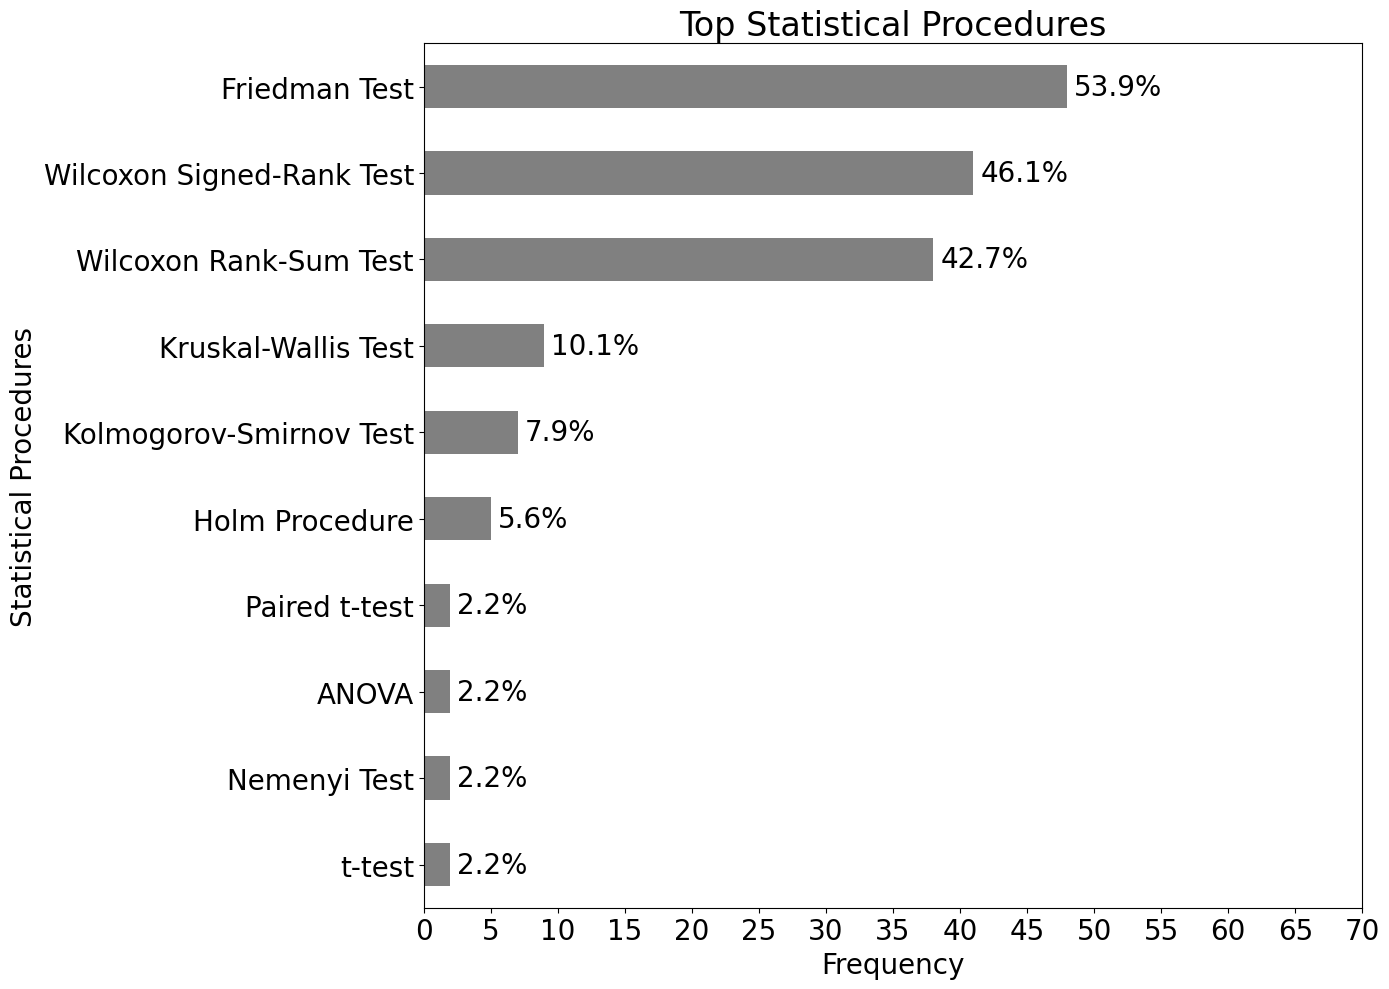

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Asegurar que los datos estén cargados (para independencia de la celda)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# Inicializar una lista para guardar todas las pruebas estadísticas individuales
all_statistical_tests = []
valid_entries_for_denominator = [] # To hold the entries from valid rows that constitute the denominator

# Iterar a través de la columna 'Statistical Analysis' y aplicar filtrado a nivel de fila
for entry in data['Statistical Analysis'].dropna():
    entry_str = str(entry).strip().lower()
    # Un registro es válido si su valor en 'Statistical Analysis' no contiene
    # "not available" Y no contiene "descriptive statistics only"
    if 'not available' not in entry_str and 'descriptive statistics only' not in entry_str:
        valid_entries_for_denominator.append(entry) # Este registro contribuye al denominador
        # Además, dividir esta entrada válida en pruebas estadísticas individuales
        all_statistical_tests.extend([test.strip() for test in entry.split(';')])

# El denominador para los porcentajes es el conteo de registros válidos
denominator_for_percentages = len(valid_entries_for_denominator)

# Obtener la frecuencia de cada prueba estadística
statistical_test_counts = pd.Series(all_statistical_tests).value_counts()

# --- BEGIN MODIFICATION: Reverting grouping and increasing font sizes ---
# Instead of grouping 'Others', we will take the top N entries, e.g., the original top 15
# Or, if 'ANOVA' was the explicit cutoff, we can take elements up to 'ANOVA' and disregard 'Others'
# Based on previous prompt, user asked to combine elements *after* ANOVA in 'Others'.
# So, to remove 'Others', we should display elements up to ANOVA (inclusive).

if 'ANOVA' in statistical_test_counts.index:
    anova_index = statistical_test_counts.index.get_loc('ANOVA')
    plot_data = statistical_test_counts.iloc[:anova_index + 1]
else:
    # Fallback if ANOVA is not found, take the top 15 most frequent tests
    plot_data = statistical_test_counts.head(15)

# Remove 'Descriptive Statistics Only' from plot_data as requested
# This line will now be largely redundant if 'Descriptive Statistics Only' is already excluded from all_statistical_tests,
# but keeping it for robustness in case of partial matches or other edge cases.
plot_data = plot_data.drop(labels=['Descriptive Statistics Only'], errors='ignore')

# Recalculate percentages for the new plot_data using the corrected denominator
# If denominator is 0, set percentages to 0 to avoid division by zero.
if denominator_for_percentages > 0:
    percentages = (plot_data / denominator_for_percentages) * 100
else:
    percentages = pd.Series(0, index=plot_data.index)

# Crear el gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(14, 10))
plot_data.sort_values().plot(kind='barh', ax=ax, color='#808080') # Ordenar para mejor visualización

# Añadir título y etiquetas con tamaños de fuente aumentados
ax.set_title('Top Statistical Procedures', fontsize=24)
ax.set_xlabel('Frequency', fontsize=20)
ax.set_ylabel('Statistical Procedures', fontsize=20)

# Establecer límites y marcas del eje x para visualizar mejor los porcentajes
max_frequency_tests = plot_data.max()
ax.set_xlim(0, 70) # Extend x-axis to 70 as requested
ax.set_xticks(np.arange(0, 71, 5)) # Set ticks every 5 units up to 70

# Aumentar el tamaño de fuente de las etiquetas de las marcas
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Anotar cada barra con su frecuencia y porcentaje
for i, (test, count) in enumerate(plot_data.sort_values().items()):
    # Retrieve the percentage calculated with the new denominator
    percentage_value = percentages.loc[test]
    ax.annotate(f'{percentage_value:.1f}%',
                (count, i),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=20, color='black')

plt.tight_layout() # Ajustar el diseño para evitar la superposición de etiquetas
plt.savefig('Fig 12 top_statistical_tests_bar_chart.svg', format='svg')
plt.show()

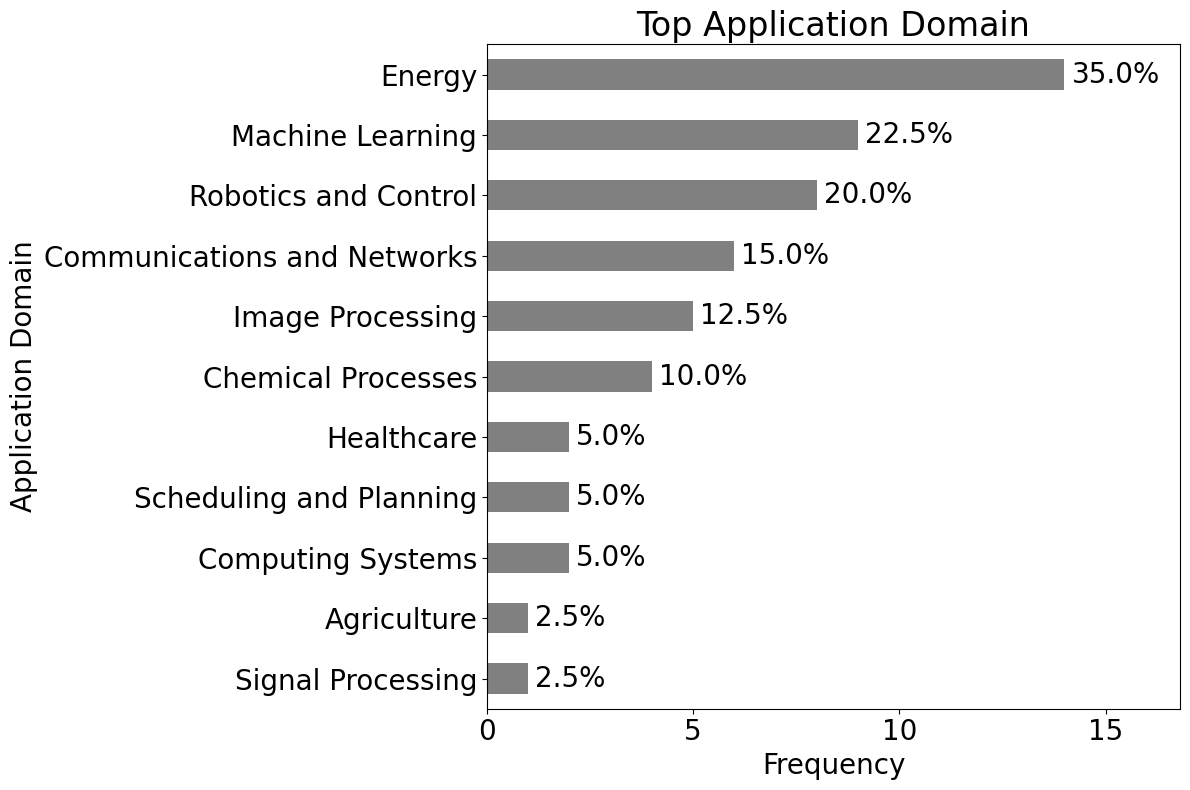

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Asegurar que los datos estén cargados (para independencia de la celda)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# --- Nuevo cálculo para el denominador de los porcentajes ---
# Contar el número de registros (filas) que NO son 'Not Applicable' o 'Not available'
num_valid_records = 0
for entry in data['Application Domain'].dropna():
    if entry.strip().lower() not in ['not applicable', 'not available']:
        num_valid_records += 1
# ----------------------------------------------------------

# Inicializar una lista para guardar todos los dominios de aplicación individuales
all_application_domains = []

# Iterar a través de la columna 'Application Domain'
for entry in data['Application Domain'].dropna():
    if entry.strip().lower() not in ['not applicable', 'not available']:
        # Dividir por punto y coma y extender la lista, eliminando espacios en blanco de cada dominio
        all_application_domains.extend([domain.strip() for domain in entry.split(';')])

# Obtener la frecuencia de cada dominio de aplicación
domain_counts = pd.Series(all_application_domains).value_counts()

# Calcular los porcentajes utilizando num_valid_records como denominador
# Si no hay registros válidos, los porcentajes son 0 para evitar división por cero.
if num_valid_records > 0:
    percentages = (domain_counts / num_valid_records) * 100
else:
    percentages = pd.Series(0, index=domain_counts.index)

# Crear el gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(12, 8)) # Ajustar el tamaño de la figura para mejor visualización
domain_counts.sort_values().plot(kind='barh', ax=ax, color='#808080') # Ordenar para mejor visualización

# Añadir título y etiquetas
ax.set_title('Top Application Domain', fontsize=24)
ax.set_xlabel('Frequency', fontsize=20)
ax.set_ylabel('Application Domain', fontsize=20)

# Ajustar el tamaño de fuente de las etiquetas de los ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Establecer límites y marcas del eje x para visualizar mejor los porcentajes
max_frequency = domain_counts.max()
ax.set_xlim(0, max_frequency * 1.2) # Extender el eje x en un 20% para dejar espacio para las anotaciones
ax.set_xticks(np.arange(0, max_frequency * 1.2 + 1, 5)) # Establecer ticks cada 5 unidades

# Anotar cada barra con su frecuencia y porcentaje
for i, (domain, count) in enumerate(domain_counts.sort_values().items()):
    # Recuperar el porcentaje calculado con el nuevo denominador
    percentage_value = percentages.loc[domain]
    ax.annotate(f'{percentage_value:.1f}%',
                (count, i),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points',
                fontsize=20, color='black')

plt.tight_layout() # Ajustar el diseño para evitar la superposición de etiquetas
plt.savefig('Fig 13 application_domain_bar_chart.svg', format='svg') # Guardar la figura
plt.show()

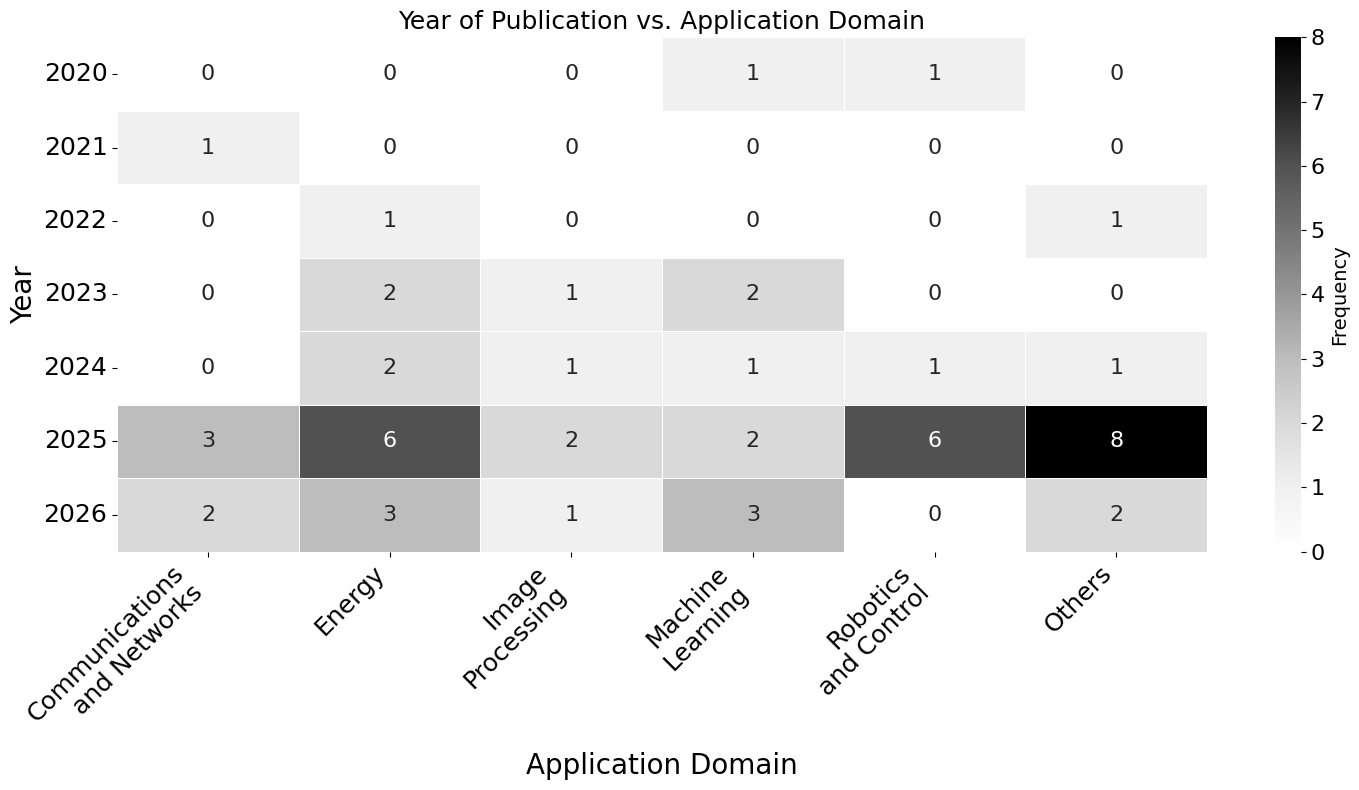

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import re # Import regex module

# Ensure data is loaded (for cell independence)
data = pd.read_excel('base_datos_clasificada_completa new proposals.xlsx')

# Filter out 'Not Applicable' and 'Not available' from the raw data before counting
filtered_application_domains = data['Application Domain'].dropna().apply(lambda x: str(x).strip())
filtered_application_domains = filtered_application_domains[~filtered_application_domains.isin(['Not Applicable', 'Not available'])]

# Recalcular las frecuencias de 'Application Domain' para aplicar la agrupación
application_domain_counts = filtered_application_domains.value_counts()

# Define el umbral para agrupar (por ejemplo, agrupar frecuencias de 2 o menos en 'Others')
threshold = 2 # You can adjust this threshold as needed

# Crear un mapeo para agrupar los dominios de aplicación
# Ensure that 'Not Applicable' and 'Not available' are not in these keys
application_domain_mapping_keys = application_domain_counts[application_domain_counts > threshold].index.tolist()

# Function to split and process 'Application Domain' entries
def process_application_domain(entry):
    if pd.isna(entry): # Handle NaN values
        return []
    entry_str = str(entry).strip()
    # Exclude 'Not Applicable' and 'Not available' at this stage as well
    if entry_str in ['Not Applicable', 'Not available']:
        return []
    individual_domains = [domain.strip() for domain in re.split(r';\s*', entry_str) if domain.strip() != '']
    return [domain if domain in application_domain_mapping_keys else 'Others' for domain in individual_domains]

# Apply the processing to create a new DataFrame for contingency table
processed_domains = data['Application Domain'].apply(process_application_domain)

# Create a list of (year, grouped_domain) pairs for each article
records_for_contingency = []
for index, row in data.iterrows():
    year = row['Year']
    domains = processed_domains.iloc[index]
    for domain in domains:
        # This check is now redundant if process_application_domain is correct, but kept for robustness
        if domain != 'Not Applicable' and domain != 'Not available':
            records_for_contingency.append({'Year': year, 'Grouped Application Domain': domain})

contingency_df = pd.DataFrame(records_for_contingency)

# Create the contingency table (pivot table) of Year vs. Grouped Application Domain
contingency_table_domain = pd.crosstab(contingency_df['Year'], contingency_df['Grouped Application Domain'])

# Ensure 'Others' is the last column if it exists
if 'Others' in contingency_table_domain.columns:
    cols_domain = contingency_table_domain.columns.tolist()
    cols_domain.remove('Others')
    cols_domain.append('Others')
    contingency_table_domain = contingency_table_domain[cols_domain]

# Create the heatmap
plt.figure(figsize=(15, 8)) # Adjusted figure size to match Fig 9
ax = sns.heatmap(contingency_table_domain, annot=True, fmt='d', cmap='Greys', linewidths=.5, cbar_kws={'label': 'Number of Articles'}, annot_kws={'fontsize': 16}) # Adjusted annot_kws to match Fig 9

# Get the colorbar object and set its label fontsize separately
cbar = ax.collections[0].colorbar
cbar.set_label('Frequency', fontsize=14) # Adjusted fontsize to match Fig 9
cbar.ax.tick_params(labelsize=16) # Adjusted fontsize to match Fig 9

# Add title and labels in English
plt.title('Year of Publication vs. Application Domain', fontsize=18) # Adjusted fontsize to match Fig 9
plt.xlabel('Application Domain', fontsize=20) # Adjusted fontsize to match Fig 9
plt.ylabel('Year', fontsize=20) # Adjusted fontsize to match Fig 9
plt.xticks(rotation=45, ha='right', fontsize=18) # Adjusted fontsize to match Fig 9
plt.yticks(rotation=0, fontsize=18) # Adjusted fontsize to match Fig 9

# --- BEGIN MODIFICATION for multiline x-axis labels ---
current_labels = [item.get_text() for item in ax.get_xticklabels()]
new_labels = []
for label in current_labels:
    if len(label) > 15 and ' ' in label: # Heuristic: if label is long and contains a space
        parts = label.split(' ')
        if len(parts) > 1:
            mid_point = len(parts) // 2
            # Try to split around the middle space
            new_label = ' '.join(parts[:mid_point]) + '\n' + ' '.join(parts[mid_point:])
        else: # No space to split, but still long
            new_label = label # Keep as is, rotation should help
    else:
        new_label = label
    new_labels.append(new_label)
ax.set_xticklabels(new_labels)
# --- END MODIFICATION for multiline x-axis labels ---

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('Fig 14 year_application_domain_heatmap.svg', format='svg') # Save the figure
plt.show()